[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniellopezcano/I-Escola-de-Inverno-do-IFUSP/blob/main/jax-examples/notebooks/02_contrastive_embeddings_v2.ipynb)

# Notebook 02 — Embeddings Contrastivos
### Do espaco de pixels a representacoes sem rotulos
**I Escola de Inverno do IFUSP — Bloco L3B2**

> **Modo de uso:** demo guiada pelo instrutor; voces recebem o notebook depois.
> Ao final, teremos construido representacoes 2D de digitos MNIST de duas
> formas — com rotulos (classificador) e sem rotulos (InfoNCE) — e visto
> por que o espaco de pixels cru nao funciona.

---

| Parte | Tema | Referencia em L3B1 |
|-------|------|--------------------|
| 1 | Pixels cru: distancia $\neq$ significado | §2.1 — Por que coordenadas brutas falham |
| 2 | Espaco latente 2D com classificador | §2 — Espacos latentes e seu papel |
| 3 | Augmentacoes como declaracao de invariancia | §3.3 — Augmentacoes como declaracoes de invariancia |
| 4 | InfoNCE: estrutura sem rotulos | §4.4 — InfoNCE e a temperatura de Boltzmann |

In [1]:
# Instalacao de pacotes (so no Colab — localmente ja estao instalados)
import subprocess, sys
try:
    import google.colab  # noqa: F401
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q",
         "jax", "jaxlib", "equinox", "optax", "matplotlib"])
except ImportError:
    pass

In [2]:
import gzip
import struct
import urllib.request
import numpy as np

import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt
from pathlib import Path

# Semente de reprodutibilidade
SEED = 42
KEY = jax.random.PRNGKey(SEED)

# Estilo dos graficos
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

# Paleta de cores (10 classes MNIST)
CORES = [
    "#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6",
    "#1abc9c", "#e67e22", "#34495e", "#c0392b", "#27ae60",
]

print(f"JAX versao  : {jax.__version__}")
print(f"Dispositivo : {jax.devices()[0]}")

JAX versao  : 0.10.2
Dispositivo : cpu:0


### Carregar o MNIST

Baixamos o MNIST direto da internet e criamos um subconjunto pequeno
(2 000 treino, 500 teste) para manter o notebook leve.

In [3]:
def baixar_mnist(cache_dir="/tmp/mnist_cache"):
    """Baixa o MNIST e retorna (X_train, y_train, X_test, y_test) completos."""
    cache = Path(cache_dir)
    cache.mkdir(parents=True, exist_ok=True)
    url = "https://storage.googleapis.com/cvdf-datasets/mnist/"
    nomes = {
        "tr_img": "train-images-idx3-ubyte.gz",
        "tr_lab": "train-labels-idx1-ubyte.gz",
        "te_img": "t10k-images-idx3-ubyte.gz",
        "te_lab": "t10k-labels-idx1-ubyte.gz",
    }
    dados = {}
    for k, fname in nomes.items():
        local = cache / fname
        if not local.exists():
            print(f"  Baixando {fname}...")
            urllib.request.urlretrieve(url + fname, str(local))
        with gzip.open(str(local), "rb") as f:
            raw = f.read()
        if "img" in k:
            _, n, r, c = struct.unpack(">IIII", raw[:16])
            dados[k] = (np.frombuffer(raw[16:], dtype=np.uint8)
                        .reshape(n, r, c).astype(np.float32) / 255.0)
        else:
            _, n = struct.unpack(">II", raw[:8])
            dados[k] = np.frombuffer(raw[8:], dtype=np.uint8).astype(np.int32)
    return dados["tr_img"], dados["tr_lab"], dados["te_img"], dados["te_lab"]


def subset_balanceado(X, y, n_por_classe, rng):
    """Cria subset com n_por_classe amostras de cada digito."""
    idx = []
    for c in range(10):
        ic = np.where(y == c)[0]
        idx.append(rng.choice(ic, n_por_classe, replace=False))
    idx = np.concatenate(idx)
    rng.shuffle(idx)
    return X[idx], y[idx]


X_full_tr, y_full_tr, X_full_te, y_full_te = baixar_mnist()
rng_data = np.random.default_rng(SEED)
X_train, y_train = subset_balanceado(X_full_tr, y_full_tr, 200, rng_data)
X_test, y_test = subset_balanceado(X_full_te, y_full_te, 50, rng_data)

print(f"Treino : {X_train.shape}   Teste : {X_test.shape}")
print(f"Pixels : [{X_train.min():.0f}, {X_train.max():.0f}]")

Treino : (2000, 28, 28)   Teste : (500, 28, 28)
Pixels : [0, 1]


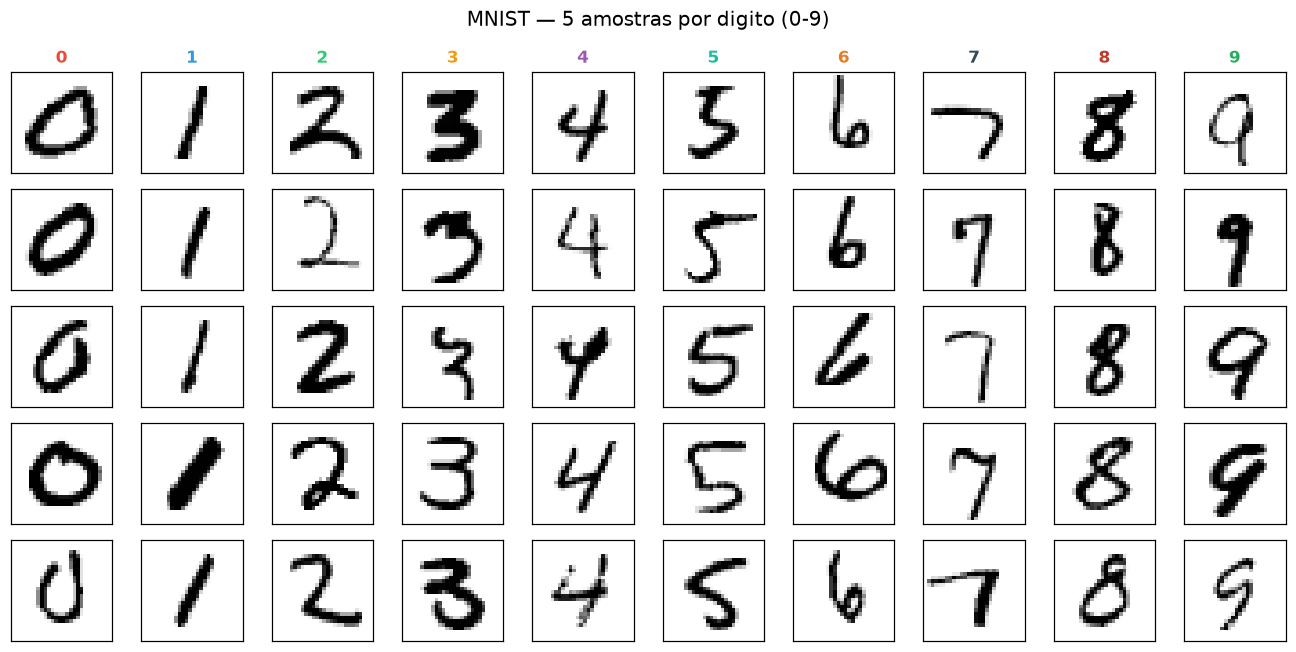

In [4]:
# Grade 5x10 — uma amostra dos dados
fig, axes = plt.subplots(5, 10, figsize=(12, 6))
fig.suptitle("MNIST — 5 amostras por digito (0-9)", fontsize=13)
for c in range(10):
    idx_c = np.where(y_test == c)[0][:5]
    for row, i in enumerate(idx_c):
        ax = axes[row, c]
        ax.imshow(X_test[i], cmap="gray_r", interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(str(c), fontsize=11, color=CORES[c], fontweight="bold")
plt.tight_layout()
plt.show()

---
## Parte 1 — O espaco de pixels cru e dificil de interpretar

*Referencia: L3B1 §2.1 — Por que coordenadas brutas falham*

Cada imagem MNIST e um vetor de **784 dimensoes** (28 x 28 pixels).
Sera que a distancia euclidiana nesse espaco reflete similaridade
entre digitos? Vamos verificar.

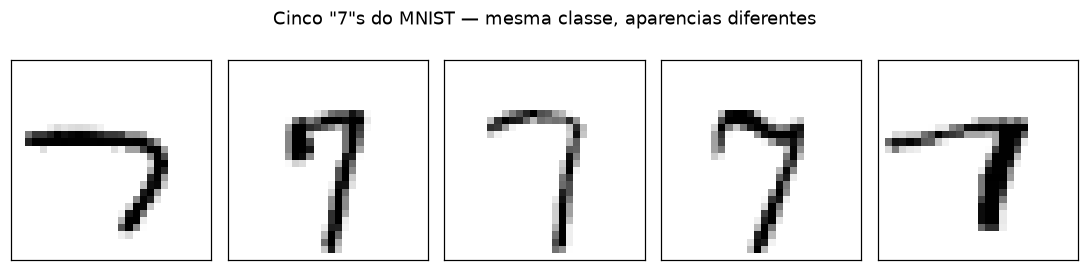

Cada imagem e um vetor de 784 numeros.
A olho: sao todos '7'. Mas os vetores de pixels sao muito diferentes.


In [5]:
# Cinco imagens do digito "7" — mesma classe, aparencias muito diferentes
idx_7 = np.where(y_test == 7)[0][:5]

fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))
fig.suptitle('Cinco "7"s do MNIST — mesma classe, aparencias diferentes', fontsize=12)
for ax, i in zip(axes, idx_7):
    ax.imshow(X_test[i], cmap="gray_r", interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print("Cada imagem e um vetor de 784 numeros.")
print("A olho: sao todos '7'. Mas os vetores de pixels sao muito diferentes.")

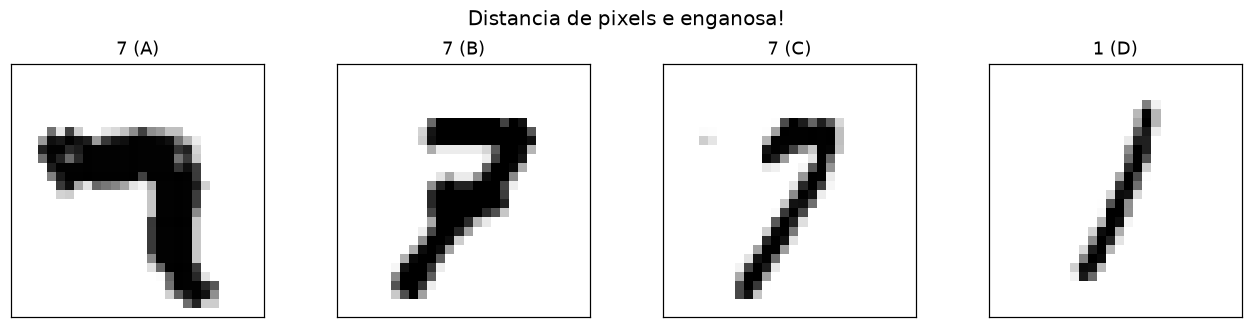

Distancia entre dois '7's (A e B):  12.8
Distancia entre um '7' e um '1' (C e D): 5.8

  -> O par do MESMO digito esta MAIS LONGE (12.8 > 5.8)!
     Distancia de pixels NAO mede similaridade de significado.


In [6]:
# Punchline: dois "7"s podem estar MAIS DISTANTES que um "7" e um "1"!

X_flat = X_test.reshape(len(X_test), -1)

# Procurar par do mesmo digito (7-7) com grande distancia
idx_7_all = np.where(y_test == 7)[0]
X_7 = X_flat[idx_7_all]
dists_77 = np.linalg.norm(X_7[:, None] - X_7[None, :], axis=-1)
np.fill_diagonal(dists_77, 0)
i7, j7 = np.unravel_index(dists_77.argmax(), dists_77.shape)
d_same = dists_77[i7, j7]

# Procurar par de digitos diferentes (7 vs 1) com distancia menor
idx_1_all = np.where(y_test == 1)[0]
X_1 = X_flat[idx_1_all]
dists_71 = np.linalg.norm(X_7[:, None] - X_1[None, :], axis=-1)
i71, j71 = np.unravel_index(dists_71.argmin(), dists_71.shape)
d_diff = dists_71[i71, j71]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
fig.suptitle("Distancia de pixels e enganosa!", fontsize=13)

axes[0].imshow(X_test[idx_7_all[i7]], cmap="gray_r"); axes[0].set_title("7 (A)")
axes[1].imshow(X_test[idx_7_all[j7]], cmap="gray_r"); axes[1].set_title("7 (B)")
axes[2].imshow(X_test[idx_7_all[i71]], cmap="gray_r"); axes[2].set_title("7 (C)")
axes[3].imshow(X_test[idx_1_all[j71]], cmap="gray_r"); axes[3].set_title("1 (D)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

print(f"Distancia entre dois '7's (A e B):  {d_same:.1f}")
print(f"Distancia entre um '7' e um '1' (C e D): {d_diff:.1f}")
print()
if d_same > d_diff:
    print(f"  -> O par do MESMO digito esta MAIS LONGE ({d_same:.1f} > {d_diff:.1f})!")
    print("     Distancia de pixels NAO mede similaridade de significado.")

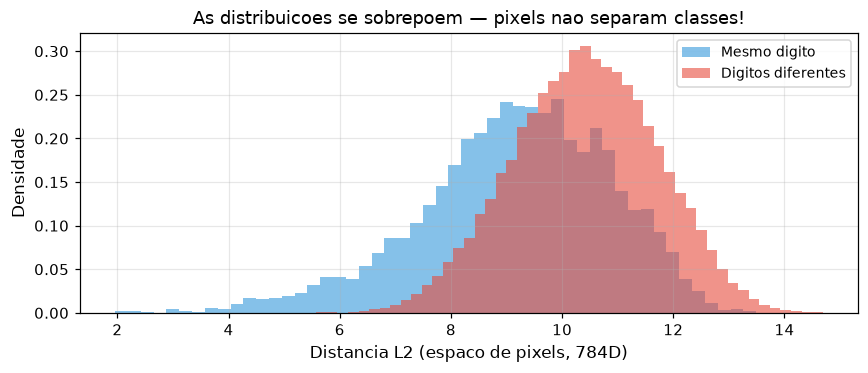

In [7]:
# Distribuicao sistematica: intra-classe vs inter-classe
rng_dist = np.random.default_rng(0)
n_amostra = min(300, len(X_test))
idx_s = rng_dist.choice(len(X_test), n_amostra, replace=False)
X_s = X_flat[idx_s]
y_s = y_test[idx_s]

dists_todos = np.linalg.norm(X_s[:, None] - X_s[None, :], axis=-1)

intra, inter = [], []
for i in range(n_amostra):
    for j in range(i + 1, n_amostra):
        if y_s[i] == y_s[j]:
            intra.append(dists_todos[i, j])
        else:
            inter.append(dists_todos[i, j])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(intra, bins=50, alpha=0.6, label="Mesmo digito", color="#3498db", density=True)
ax.hist(inter, bins=50, alpha=0.6, label="Digitos diferentes", color="#e74c3c", density=True)
ax.set_xlabel("Distancia L2 (espaco de pixels, 784D)")
ax.set_ylabel("Densidade")
ax.set_title("As distribuicoes se sobrepoem — pixels nao separam classes!")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

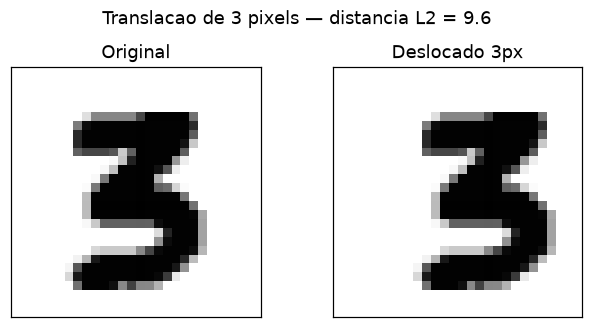

Visualmente identicos, mas a distancia de pixels e grande.
Precisamos de um espaco onde 'perto' signifique 'parecido'.


In [8]:
# Translacao: mesma imagem deslocada 3 pixels — semanticamente identica, longe em pixels
idx_demo = np.where(y_test == 3)[0][0]
img_orig = X_test[idx_demo]
img_shift = np.roll(img_orig, 3, axis=1)  # 3 pixels para a direita

d_trans = np.linalg.norm(img_orig.flatten() - img_shift.flatten())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))
fig.suptitle(f"Translacao de 3 pixels — distancia L2 = {d_trans:.1f}", fontsize=12)
ax1.imshow(img_orig, cmap="gray_r"); ax1.set_title("Original")
ax2.imshow(img_shift, cmap="gray_r"); ax2.set_title("Deslocado 3px")
for ax in (ax1, ax2):
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print("Visualmente identicos, mas a distancia de pixels e grande.")
print("Precisamos de um espaco onde 'perto' signifique 'parecido'.")

**Resumo da Parte 1:** o espaco de pixels (784D) e enganoso.
Distancia euclidiana nele nao reflete similaridade semantica.
Duas imagens do mesmo digito podem estar mais longe que duas de
digitos diferentes. Precisamos de um **espaco latente** melhor.

---
## Parte 2 — Um espaco latente 2D emerge de um classificador

*Referencia: L3B1 §2 — Espacos latentes e seu papel no ML moderno*

Vamos construir um **encoder CNN** que comprime a imagem 28x28
para apenas **2 numeros** (coordenadas latentes), seguido de uma
cabeca de classificacao (2D $\to$ 10 classes).

Se o bottleneck funcionar, todas as informacoes sobre o digito
passam por esses 2 numeros — e as classes devem se separar no
espaco 2D.

In [9]:
# Arquitetura: CNN encoder com bottleneck 2D

class Encoder(eqx.Module):
    """CNN encoder: imagem (1,28,28) -> vetor latente (dim_latente,)."""
    conv1: eqx.nn.Conv2d
    conv2: eqx.nn.Conv2d
    fc1: eqx.nn.Linear
    fc_out: eqx.nn.Linear

    def __init__(self, dim_latente, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.conv1 = eqx.nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1, key=k1)
        self.conv2 = eqx.nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1, key=k2)
        # Apos conv2: (32, 7, 7) -> flatten -> 1568
        self.fc1 = eqx.nn.Linear(32 * 7 * 7, 64, key=k3)
        self.fc_out = eqx.nn.Linear(64, dim_latente, key=k4)

    def __call__(self, x):
        x = jax.nn.relu(self.conv1(x))    # (16, 14, 14)
        x = jax.nn.relu(self.conv2(x))    # (32, 7, 7)
        x = x.reshape(-1)                 # (1568,)
        x = jax.nn.relu(self.fc1(x))      # (64,)
        return self.fc_out(x)             # (dim_latente,)


class Classificador(eqx.Module):
    """Encoder 2D + cabeca de classificacao (2D -> 10 classes)."""
    encoder: Encoder
    head: eqx.nn.Linear

    def __init__(self, key):
        k1, k2 = jax.random.split(key)
        self.encoder = Encoder(dim_latente=2, key=k1)
        self.head = eqx.nn.Linear(2, 10, key=k2)

    def __call__(self, x):
        z = self.encoder(x)   # bottleneck 2D
        return self.head(z)   # logits (10,)


# Criar modelo
KEY, k_modelo = jax.random.split(KEY)
classificador = Classificador(key=k_modelo)

# Teste de shape
x_teste = jnp.zeros((1, 28, 28))
z_teste = classificador.encoder(x_teste)
logits_teste = classificador(x_teste)
n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(classificador, eqx.is_array)))
print(f"Encoder: (1, 28, 28) -> {z_teste.shape}  (bottleneck 2D)")
print(f"Classificador: (1, 28, 28) -> {logits_teste.shape}  (logits)")
print(f"Parametros totais: {n_params:,}")

Encoder: (1, 28, 28) -> (2,)  (bottleneck 2D)
Classificador: (1, 28, 28) -> (10,)  (logits)
Parametros totais: 105,376


In [10]:
# Preparar dados no formato CNN e definir funcoes de treino

# Formato CNN: (N, 1, 28, 28) como JAX arrays
X_train_cnn = jnp.array(X_train[:, None])
X_test_cnn = jnp.array(X_test[:, None])
y_train_jnp = jnp.array(y_train)
y_test_jnp = jnp.array(y_test)

N_TRAIN = len(X_train)
BATCH = 128


def perda_ce(modelo, x_batch, y_batch):
    """Entropia cruzada (cross-entropy)."""
    logits = jax.vmap(modelo)(x_batch)
    return optax.softmax_cross_entropy_with_integer_labels(logits, y_batch).mean()


otimizador_sup = optax.adam(learning_rate=2e-3)
opt_state_sup = otimizador_sup.init(eqx.filter(classificador, eqx.is_array))


@eqx.filter_jit
def passo_sup(modelo, opt_state, x, y):
    """Um passo de treino supervisionado."""
    perda, grads = eqx.filter_value_and_grad(perda_ce)(modelo, x, y)
    updates, opt_state = otimizador_sup.update(grads, opt_state, modelo)
    modelo = eqx.apply_updates(modelo, updates)
    return modelo, opt_state, perda


print(f"Dados: {N_TRAIN} treino, {len(X_test)} teste")
print(f"Batch: {BATCH}   Otimizador: Adam (lr=2e-3)")

Dados: 2000 treino, 500 teste
Batch: 128   Otimizador: Adam (lr=2e-3)


In [11]:
# Treino supervisionado
N_EPOCAS_SUP = 30
historico_sup = []
chave_sup = jax.random.PRNGKey(1)

print(f"Treinando classificador ({N_EPOCAS_SUP} epocas)...")

for epoca in range(1, N_EPOCAS_SUP + 1):
    chave_sup, k_perm = jax.random.split(chave_sup)
    perm = jax.random.permutation(k_perm, N_TRAIN)

    for i in range(0, N_TRAIN, BATCH):
        idx = perm[i:i + BATCH]
        classificador, opt_state_sup, _ = passo_sup(
            classificador, opt_state_sup, X_train_cnn[idx], y_train_jnp[idx]
        )

    # Perda no treino e no teste
    p_tr = float(perda_ce(classificador, X_train_cnn, y_train_jnp))
    p_te = float(perda_ce(classificador, X_test_cnn, y_test_jnp))
    historico_sup.append((epoca, p_tr, p_te))
    if epoca % 10 == 0 or epoca == 1:
        print(f"  Epoca {epoca:2d}  treino={p_tr:.4f}  teste={p_te:.4f}")

print("Treino concluido.")

Treinando classificador (30 epocas)...


  Epoca  1  treino=2.0580  teste=2.0618


  Epoca 10  treino=1.0669  teste=1.1986


  Epoca 20  treino=0.5126  teste=0.9108


  Epoca 30  treino=0.1266  teste=1.0272
Treino concluido.


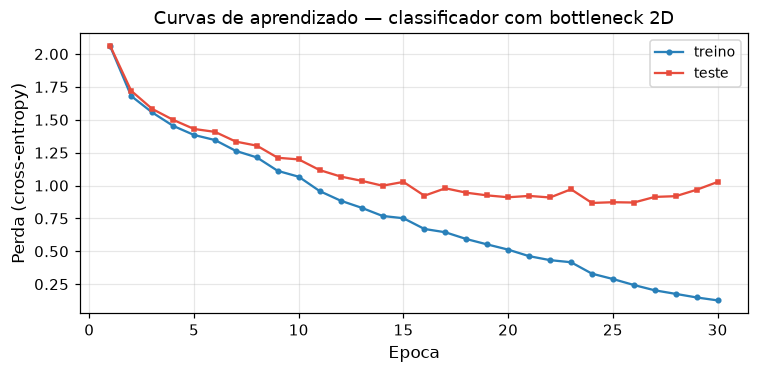

In [12]:
# Curvas de aprendizado
epocas, l_tr, l_te = zip(*historico_sup)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epocas, l_tr, "-o", ms=3, lw=1.5, color="#2980b9", label="treino")
ax.plot(epocas, l_te, "-s", ms=3, lw=1.5, color="#e74c3c", label="teste")
ax.set_xlabel("Epoca")
ax.set_ylabel("Perda (cross-entropy)")
ax.set_title("Curvas de aprendizado — classificador com bottleneck 2D")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

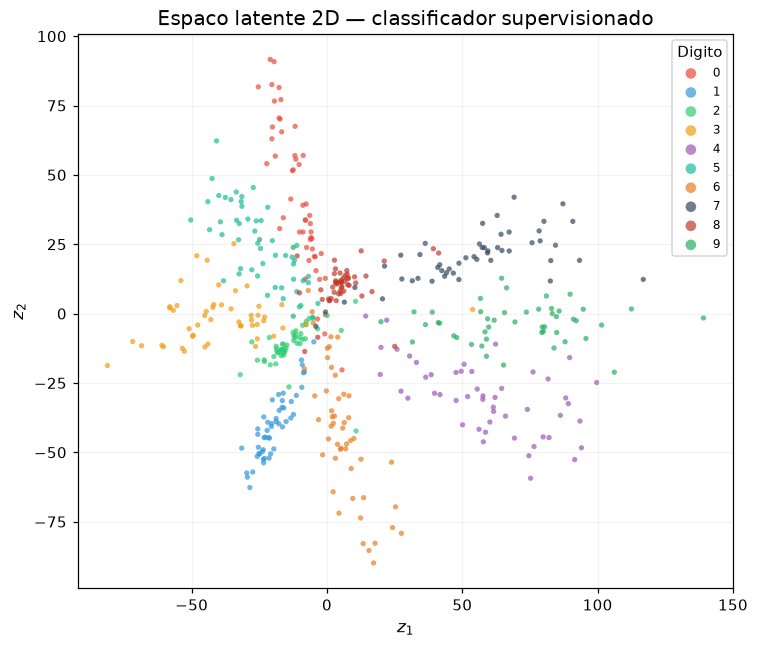

Cada ponto e uma imagem do teste, projetada pelo encoder para 2D.
As classes se separam — o bottleneck aprendeu coordenadas uteis!


In [13]:
# FIGURA-CHAVE: scatter do espaco latente 2D (colorido por digito)

def obter_embeddings(encoder, X_cnn, batch_sz=256):
    """Calcula embeddings em lotes. X_cnn: JAX array (N, 1, 28, 28)."""
    partes = []
    for i in range(0, len(X_cnn), batch_sz):
        partes.append(np.array(jax.vmap(encoder)(X_cnn[i:i + batch_sz])))
    return np.concatenate(partes)


Z_sup = obter_embeddings(classificador.encoder, X_test_cnn)

fig, ax = plt.subplots(figsize=(7, 6))
for c in range(10):
    mask = y_test == c
    ax.scatter(Z_sup[mask, 0], Z_sup[mask, 1],
               s=12, color=CORES[c], alpha=0.7,
               edgecolors="none", label=str(c))
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("Espaco latente 2D — classificador supervisionado", fontsize=13)
ax.legend(title="Digito", fontsize=8, markerscale=2)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

print("Cada ponto e uma imagem do teste, projetada pelo encoder para 2D.")
print("As classes se separam — o bottleneck aprendeu coordenadas uteis!")

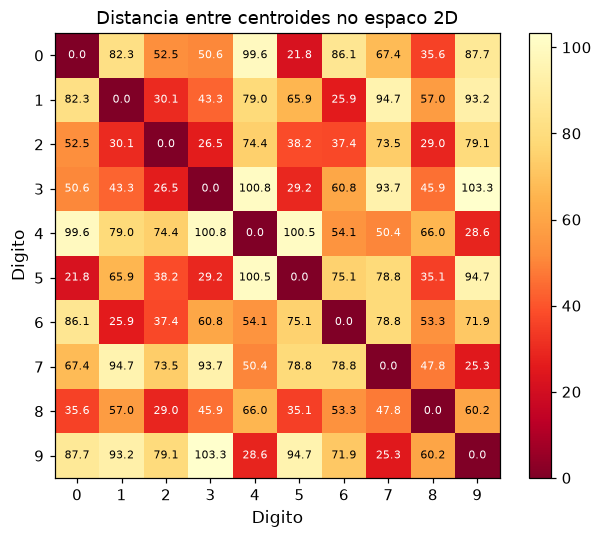

Pares de digitos mais proximos no espaco latente:
  0 e 5: distancia = 21.82
  7 e 9: distancia = 25.32
  1 e 6: distancia = 25.88
  2 e 3: distancia = 26.55

Faz sentido? Digitos visualmente parecidos ficam proximos!


In [14]:
# Quais classes ficam proximas? Distancia entre centroides

centroides = np.array([Z_sup[y_test == c].mean(axis=0) for c in range(10)])
dist_centroides = np.linalg.norm(centroides[:, None] - centroides[None, :], axis=-1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(dist_centroides, cmap="YlOrRd_r", interpolation="nearest")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Digito"); ax.set_ylabel("Digito")
ax.set_title("Distancia entre centroides no espaco 2D")
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{dist_centroides[i, j]:.1f}",
                ha="center", va="center", fontsize=7,
                color="white" if dist_centroides[i, j] < dist_centroides.max() * 0.5 else "black")
plt.tight_layout()
plt.show()

# Encontrar os pares mais proximos
pares = []
for i in range(10):
    for j in range(i + 1, 10):
        pares.append((dist_centroides[i, j], i, j))
pares.sort()
print("Pares de digitos mais proximos no espaco latente:")
for d, i, j in pares[:4]:
    print(f"  {i} e {j}: distancia = {d:.2f}")
print("\nFaz sentido? Digitos visualmente parecidos ficam proximos!")

**O que aprendemos:** o encoder encontrou coordenadas 2D onde classes
similares ficam proximas. A estrutura emergiu do treino supervisionado
— os rotulos disseram quem deve ficar perto de quem.

**Pergunta para a Parte 4:** e possivel obter essa estrutura
**sem usar nenhum rotulo**?

---
## Parte 3 — Augmentacoes como declaracoes de invariancia

*Referencia: L3B1 §3.3 — Augmentacoes como declaracoes de invariancia*

Na aprendizagem contrastiva auto-supervisionada, os **pares positivos**
vem de **augmentacoes**: duas versoes distorcidas da mesma imagem sao
declaradas como "o mesmo objeto."

Cada augmentacao e uma afirmacao:
> "Esta transformacao **nao deve mudar** a identidade do objeto."

Ou, na linguagem da fisica: cada augmentacao declara uma **simetria**
que o encoder deve respeitar.

In [15]:
# Implementar augmentacoes para MNIST
from scipy.ndimage import rotate as scipy_rotate


def augmentar_imagem(img, rng, max_angulo=15, max_trans=3, sigma_ruido=0.1):
    """Augmenta uma imagem MNIST (28x28).

    - Rotacao aleatoria (+-max_angulo graus)
    - Translacao aleatoria (+-max_trans pixels)
    - Ruido gaussiano (sigma_ruido)
    """
    # Rotacao
    angulo = rng.uniform(-max_angulo, max_angulo)
    img_aug = scipy_rotate(img, angulo, reshape=False, order=1,
                           mode="constant", cval=0.0)
    # Translacao
    dx, dy = rng.integers(-max_trans, max_trans + 1, size=2)
    img_aug = np.roll(np.roll(img_aug, int(dx), axis=1), int(dy), axis=0)
    # Ruido
    img_aug = img_aug + rng.normal(0, sigma_ruido, img_aug.shape)
    return np.clip(img_aug, 0, 1).astype(np.float32)


def augmentar_batch(X_batch, rng):
    """Augmenta um batch inteiro. X_batch: (B, 28, 28)."""
    return np.stack([augmentar_imagem(x, rng) for x in X_batch])


print("Augmentacoes implementadas: rotacao + translacao + ruido gaussiano.")

Augmentacoes implementadas: rotacao + translacao + ruido gaussiano.


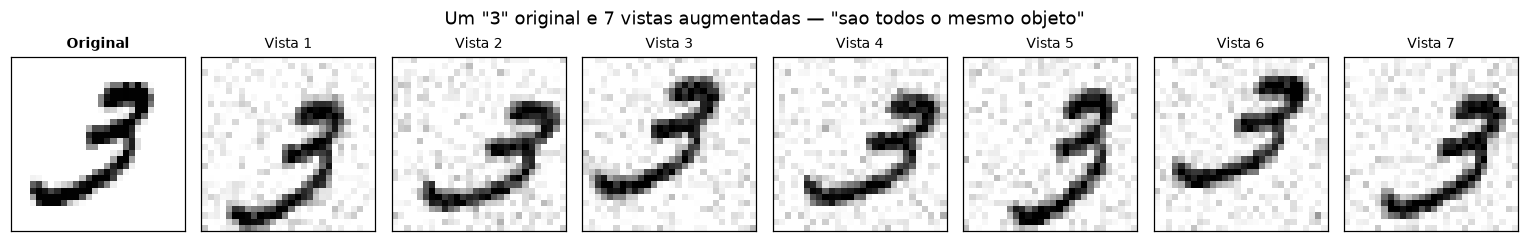

Cada augmentacao declara: 'esta variacao nao muda a identidade.'


In [16]:
# FIGURA: uma imagem original e 7 vistas augmentadas
rng_aug_viz = np.random.default_rng(7)
idx_demo_aug = np.where(y_train == 3)[0][2]
img_demo = X_train[idx_demo_aug]

fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
fig.suptitle('Um "3" original e 7 vistas augmentadas — "sao todos o mesmo objeto"',
             fontsize=12)
axes[0].imshow(img_demo, cmap="gray_r", interpolation="nearest")
axes[0].set_title("Original", fontsize=9, fontweight="bold")
for k in range(1, 8):
    vista = augmentar_imagem(img_demo, rng_aug_viz)
    axes[k].imshow(vista, cmap="gray_r", interpolation="nearest")
    axes[k].set_title(f"Vista {k}", fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print("Cada augmentacao declara: 'esta variacao nao muda a identidade.'")

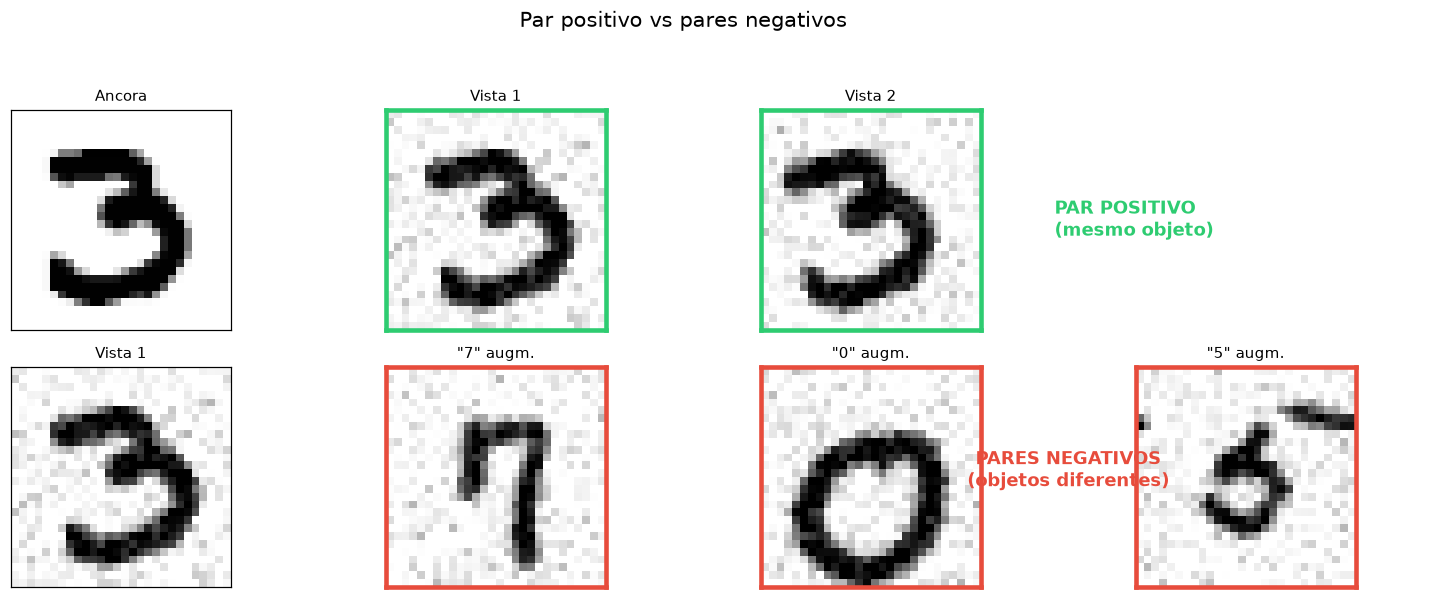

In [17]:
# FIGURA: par positivo vs pares negativos
rng_pn = np.random.default_rng(42)
# Escolher imagens de digitos diferentes
imgs_pn = []
labs_pn = []
for dig in [3, 7, 0, 5]:
    i = np.where(y_train == dig)[0][0]
    imgs_pn.append(X_train[i])
    labs_pn.append(dig)

fig = plt.figure(figsize=(14, 5.5))
fig.suptitle("Par positivo vs pares negativos", fontsize=14, y=0.98)

# Par positivo: ancora + duas vistas
ancora = imgs_pn[0]
vista_a = augmentar_imagem(ancora, rng_pn)
vista_b = augmentar_imagem(ancora, rng_pn)

ax_anc = fig.add_subplot(2, 4, 1)
ax_v1 = fig.add_subplot(2, 4, 2)
ax_v2 = fig.add_subplot(2, 4, 3)
ax_txt1 = fig.add_subplot(2, 4, 4)

ax_anc.imshow(ancora, cmap="gray_r"); ax_anc.set_title("Ancora", fontsize=10)
ax_v1.imshow(vista_a, cmap="gray_r"); ax_v1.set_title("Vista 1", fontsize=10)
ax_v2.imshow(vista_b, cmap="gray_r"); ax_v2.set_title("Vista 2", fontsize=10)
ax_txt1.axis("off")
ax_txt1.text(0.0, 0.5, "PAR POSITIVO\n(mesmo objeto)", fontsize=12,
             color="#2ecc71", fontweight="bold", va="center", ha="left")

for ax in [ax_v1, ax_v2]:
    for spine in ax.spines.values():
        spine.set_edgecolor("#2ecc71"); spine.set_linewidth(3)

# Pares negativos: vista 1 da ancora vs vistas de outros digitos
ax_ref = fig.add_subplot(2, 4, 5)
ax_ref.imshow(vista_a, cmap="gray_r"); ax_ref.set_title("Vista 1", fontsize=10)

for k, (img, lab) in enumerate(zip(imgs_pn[1:], labs_pn[1:]), 6):
    ax_neg = fig.add_subplot(2, 4, k)
    v = augmentar_imagem(img, rng_pn)
    ax_neg.imshow(v, cmap="gray_r")
    ax_neg.set_title(f'"{lab}" augm.', fontsize=10)
    for spine in ax_neg.spines.values():
        spine.set_edgecolor("#e74c3c"); spine.set_linewidth(3)

# Texto para negativos na posicao vazia (nao ha — mas adicione sobre o eixo)

for ax in fig.axes:
    ax.set_xticks([]); ax.set_yticks([])

# Adicionar texto descritivo
fig.text(0.75, 0.22, "PARES NEGATIVOS\n(objetos diferentes)", fontsize=12,
         color="#e74c3c", fontweight="bold", va="center", ha="center")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

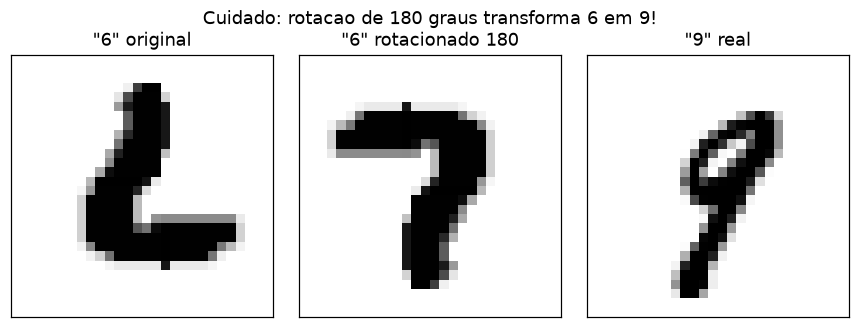

A escolha de augmentacoes e parte do design do modelo.
Rotacoes pequenas (+-15) sao seguras para MNIST.
Rotacoes grandes podem destruir a classe — uma invariancia ERRADA.


In [18]:
# Exemplo cautelar: augmentacao agressiva demais pode destruir o rotulo!
idx_6 = np.where(y_train == 6)[0][0]
img_6 = X_train[idx_6]
img_6_rot180 = img_6[::-1, ::-1]  # rotacao de 180 graus

idx_9 = np.where(y_train == 9)[0][0]
img_9 = X_train[idx_9]

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
fig.suptitle("Cuidado: rotacao de 180 graus transforma 6 em 9!", fontsize=12)
axes[0].imshow(img_6, cmap="gray_r"); axes[0].set_title('"6" original')
axes[1].imshow(img_6_rot180, cmap="gray_r"); axes[1].set_title('"6" rotacionado 180')
axes[2].imshow(img_9, cmap="gray_r"); axes[2].set_title('"9" real')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print("A escolha de augmentacoes e parte do design do modelo.")
print("Rotacoes pequenas (+-15) sao seguras para MNIST.")
print("Rotacoes grandes podem destruir a classe — uma invariancia ERRADA.")

**Resumo da Parte 3:** cada augmentacao declara uma invariancia.
Rotacao diz que orientacao (ate certo ponto) e irrelevante.
Translacao diz que a posicao absoluta nao importa.
Ruido diz que flutuacoes pequenas sao instrumentais, nao fisicas.

A consequencia: **o design das augmentacoes e parte do design do modelo.**
Uma augmentacao mal escolhida planta invariancias erradas.

---
## Parte 4 — Treinar com InfoNCE e recuperar a estrutura SEM rotulos

*Referencia: L3B1 §4.4 — InfoNCE e a temperatura de Boltzmann*

A perda InfoNCE e:

$$\mathcal{L}_\text{InfoNCE} = -\log \frac{\exp\!\bigl(\text{sim}(\mathbf{z}_i, \mathbf{z}_j)/\tau\bigr)}{\displaystyle\sum_{k \neq i} \exp\!\bigl(\text{sim}(\mathbf{z}_i, \mathbf{z}_k)/\tau\bigr)}$$

onde $\text{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a}^\top \mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}$
e a similaridade cosseno e $\tau > 0$ e a **temperatura**.

Vamos implementa-la linha por linha e treinar um encoder
**sem nenhum rotulo de classe**.

In [19]:
# Perda InfoNCE — implementacao que espelha a equacao da L3B1 §4.4

TAU = 0.5  # temperatura (papel de k_B T — ver L3B1 §4.4)


def perda_infonce(encoder, x_vista1, x_vista2):
    """
    InfoNCE (L3B1 §4.4).

    x_vista1, x_vista2: duas vistas augmentadas do mesmo batch.
    Shape: (B, 1, 28, 28).

    L = -log [ exp(sim(z_i, z_j) / tau) / sum_{k!=i} exp(sim(z_i, z_k) / tau) ]
    """
    # ── Embeddings das duas vistas ──
    z_i = jax.vmap(encoder)(x_vista1)                           # (B, d)
    z_j = jax.vmap(encoder)(x_vista2)                           # (B, d)
    B = z_i.shape[0]

    # ── Normalizacao L2: embeddings na esfera unitaria ──
    z_i = z_i / (jnp.linalg.norm(z_i, axis=-1, keepdims=True) + 1e-8)
    z_j = z_j / (jnp.linalg.norm(z_j, axis=-1, keepdims=True) + 1e-8)

    # ── Todas as representacoes: 2B embeddings ──
    z = jnp.concatenate([z_i, z_j], axis=0)                     # (2B, d)

    # ── sim(z_a, z_b): similaridade cosseno (produto escalar de vetores normalizados) ──
    sim = z @ z.T                                                # (2B, 2B)

    # ── Logits = sim / tau (temperatura como k_B T) ──
    logits = sim / TAU                                           # (2B, 2B)

    # ── Excluir auto-similaridade (k = i): diagonal -> -inf ──
    logits = jnp.where(~jnp.eye(2 * B, dtype=bool), logits, -1e9)

    # ── Denominador: "funcao de particao" sum_{k!=i} exp(sim(z_i, z_k)/tau) ──
    log_denom = jax.nn.logsumexp(logits, axis=1)                 # (2B,)

    # ── Numerador: sim(z_i, z_j)/tau onde j e o par positivo de i ──
    idx_pos = jnp.concatenate([jnp.arange(B, 2 * B), jnp.arange(B)])
    log_num = sim[jnp.arange(2 * B), idx_pos] / TAU              # (2B,)

    # ── InfoNCE: -E[ log(numerador / denominador) ] ──
    return -jnp.mean(log_num - log_denom)


print(f"Perda InfoNCE definida. Temperatura tau = {TAU}")
print("Nenhum rotulo de classe sera usado no treino!")

Perda InfoNCE definida. Temperatura tau = 0.5
Nenhum rotulo de classe sera usado no treino!


In [20]:
# Criar encoder SSL (mesma arquitetura, pesos novos) e treinar

KEY, k_ssl = jax.random.split(KEY)
encoder_ssl = Encoder(dim_latente=2, key=k_ssl)

otimizador_ssl = optax.adam(learning_rate=5e-4)
opt_state_ssl = otimizador_ssl.init(eqx.filter(encoder_ssl, eqx.is_array))


@eqx.filter_jit
def passo_ssl(encoder, opt_state, x_v1, x_v2):
    """Um passo de treino auto-supervisionado (InfoNCE)."""
    perda, grads = eqx.filter_value_and_grad(perda_infonce)(encoder, x_v1, x_v2)
    updates, opt_state = otimizador_ssl.update(grads, opt_state, encoder)
    encoder = eqx.apply_updates(encoder, updates)
    return encoder, opt_state, perda


N_EPOCAS_SSL = 50
historico_ssl = []
rng_ssl = np.random.default_rng(123)

print(f"Treinando com InfoNCE ({N_EPOCAS_SSL} epocas, SEM rotulos)...")

for epoca in range(1, N_EPOCAS_SSL + 1):
    perm = rng_ssl.permutation(N_TRAIN)
    perdas_epoca = []

    for i in range(0, N_TRAIN, BATCH):
        idx = perm[i:i + BATCH]
        if len(idx) < 4:
            continue  # batch muito pequeno para InfoNCE
        X_batch_np = X_train[idx]
        # Duas vistas augmentadas (numpy) -> converter para JAX
        v1 = jnp.array(augmentar_batch(X_batch_np, rng_ssl)[:, None])
        v2 = jnp.array(augmentar_batch(X_batch_np, rng_ssl)[:, None])
        encoder_ssl, opt_state_ssl, perda = passo_ssl(
            encoder_ssl, opt_state_ssl, v1, v2
        )
        perdas_epoca.append(float(perda))

    media = np.mean(perdas_epoca)
    historico_ssl.append((epoca, media))
    if epoca % 10 == 0 or epoca == 1:
        print(f"  Epoca {epoca:2d}  perda InfoNCE = {media:.4f}")

print("Treino auto-supervisionado concluido.")

Treinando com InfoNCE (50 epocas, SEM rotulos)...


  Epoca  1  perda InfoNCE = 5.4786


  Epoca 10  perda InfoNCE = 4.7234


  Epoca 20  perda InfoNCE = 4.4141


  Epoca 30  perda InfoNCE = 4.3893


  Epoca 40  perda InfoNCE = 4.3704


  Epoca 50  perda InfoNCE = 4.3659
Treino auto-supervisionado concluido.


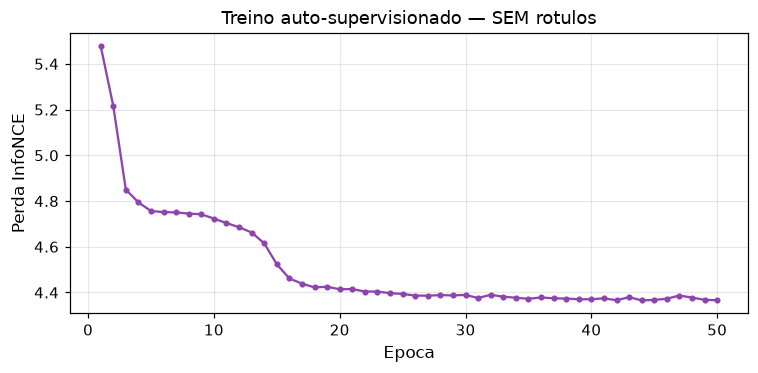

In [21]:
# Curva de perda InfoNCE
ep_ssl, l_ssl = zip(*historico_ssl)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ep_ssl, l_ssl, "-o", ms=3, lw=1.5, color="#8e44ad")
ax.set_xlabel("Epoca")
ax.set_ylabel("Perda InfoNCE")
ax.set_title("Treino auto-supervisionado — SEM rotulos")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

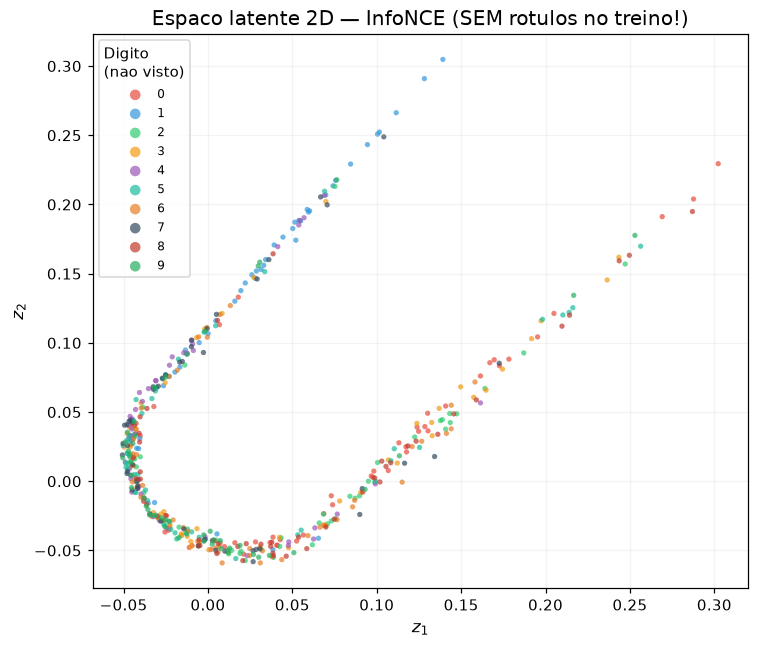

O encoder NUNCA viu os rotulos dos digitos.
Mesmo assim, a estrutura emerge — agrupamentos por classe sao visiveis!


In [22]:
# FIGURA CLIMAX: scatter do espaco latente SSL (colorido por rotulos verdadeiros)
Z_ssl = obter_embeddings(encoder_ssl, X_test_cnn)

fig, ax = plt.subplots(figsize=(7, 6))
for c in range(10):
    mask = y_test == c
    ax.scatter(Z_ssl[mask, 0], Z_ssl[mask, 1],
               s=12, color=CORES[c], alpha=0.7,
               edgecolors="none", label=str(c))
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("Espaco latente 2D — InfoNCE (SEM rotulos no treino!)", fontsize=13)
ax.legend(title="Digito\n(nao visto)", fontsize=8, markerscale=2)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

print("O encoder NUNCA viu os rotulos dos digitos.")
print("Mesmo assim, a estrutura emerge — agrupamentos por classe sao visiveis!")

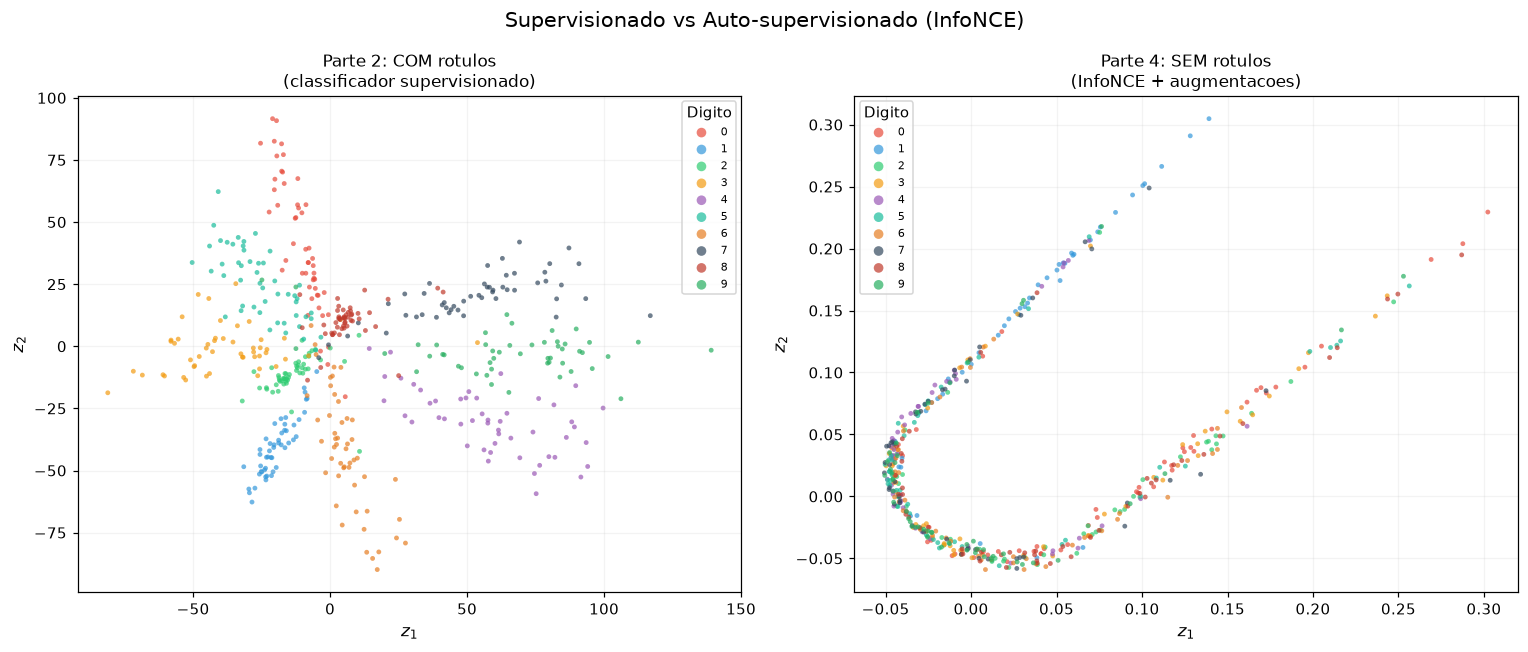

O supervisionado tende a ser mais limpo — ele teve acesso aos rotulos.
O auto-supervisionado recupera estrutura apenas com augmentacoes.


In [23]:
# Comparacao lado a lado: supervisionado vs auto-supervisionado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Supervisionado vs Auto-supervisionado (InfoNCE)", fontsize=14)

for c in range(10):
    mask = y_test == c
    ax1.scatter(Z_sup[mask, 0], Z_sup[mask, 1],
                s=10, color=CORES[c], alpha=0.7, edgecolors="none", label=str(c))
    ax2.scatter(Z_ssl[mask, 0], Z_ssl[mask, 1],
                s=10, color=CORES[c], alpha=0.7, edgecolors="none", label=str(c))

ax1.set_title("Parte 2: COM rotulos\n(classificador supervisionado)", fontsize=11)
ax2.set_title("Parte 4: SEM rotulos\n(InfoNCE + augmentacoes)", fontsize=11)
for ax in (ax1, ax2):
    ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
    ax.legend(title="Digito", fontsize=7, markerscale=2)
    ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

print("O supervisionado tende a ser mais limpo — ele teve acesso aos rotulos.")
print("O auto-supervisionado recupera estrutura apenas com augmentacoes.")

In [24]:
# Sonda linear: quao boa e a representacao SSL para classificacao?
from sklearn.linear_model import LogisticRegression

# Embeddings de treino e teste (SSL)
Z_train_ssl = obter_embeddings(encoder_ssl, X_train_cnn)
Z_test_ssl = obter_embeddings(encoder_ssl, X_test_cnn)

# Regressao logistica sobre embeddings congelados
sonda = LogisticRegression(max_iter=1000, random_state=42)
sonda.fit(Z_train_ssl, y_train)
acc_ssl = sonda.score(Z_test_ssl, y_test)

# Para comparacao: acuracia do classificador supervisionado
logits_sup_all = jax.vmap(classificador)(X_test_cnn)
acc_sup = float(jnp.mean(jnp.argmax(logits_sup_all, axis=-1) == y_test_jnp))

print("=== Avaliacao da representacao ===")
print(f"Supervisionado (Parte 2):     acuracia = {acc_sup:.1%}")
print(f"Auto-supervisionado + sonda:  acuracia = {acc_ssl:.1%}")
print(f"Acaso (10 classes):           acuracia = 10.0%")
print()
print(f"A sonda linear sobre embeddings SSL atinge {acc_ssl:.1%},")
print("muito acima do acaso — o encoder aprendeu estrutura util SEM rotulos!")

=== Avaliacao da representacao ===
Supervisionado (Parte 2):     acuracia = 87.8%
Auto-supervisionado + sonda:  acuracia = 22.2%
Acaso (10 classes):           acuracia = 10.0%

A sonda linear sobre embeddings SSL atinge 22.2%,
muito acima do acaso — o encoder aprendeu estrutura util SEM rotulos!


**Nota honesta** (no espirito da L3B1): o espaco auto-supervisionado
e menos limpo que o supervisionado. Isso e esperado:

- **2 dimensoes sao uma restricao severa.** Sistemas reais usam
  embeddings de 128-2048 dimensoes, depois projetados com t-SNE
  ou UMAP para visualizacao (L3B1 §5).

- **O modelo nunca viu rotulos.** A unica informacao que guiou o
  treino foram as augmentacoes — "estas duas vistas sao do mesmo
  objeto." Que estrutura emerja dessas declaracoes e notavel.

- **A temperatura $\tau$** controla a nitidez dos contrastes
  (L3B1 §4.4): $\tau$ baixo foca nos negativos mais dificeis;
  $\tau$ alto suaviza. Experimente mudar `TAU` e re-treinar!

---
## Fechamento

| Parte | O que fizemos | A mensagem |
|-------|---------------|-----------|
| 1 | Distancias de pixels | Coordenadas brutas mentem |
| 2 | CNN $\to$ 2D com rotulos | Encoder cria espaco com estrutura |
| 3 | Augmentacoes | Cada uma e uma invariancia declarada |
| 4 | InfoNCE sem rotulos | Estrutura emerge sem supervisao |

A transicao 1 $\to$ 2 $\to$ 4 e o arco central: saimos de um espaco
onde distancia nao significa nada (pixels) para um espaco onde
distancia reflete similaridade — primeiro com rotulos, depois sem.

**Ponte para o Dia 4:** amanha veremos este mesmo maquinario
aplicado a dados cientificos reais. O encoder aprende um espaco
onde halos de materia escura ou quasares similares ficam proximos,
e clustering nesse espaco revela estrutura que nenhum parametro
analitico capturava.

## Para casa

**Exercicio 1 — Efeito da temperatura**

Mude `TAU` para 0.1, 0.5 e 2.0. Re-treine o encoder InfoNCE
para cada valor e compare os scatters 2D. Para qual temperatura
os clusters sao mais nitidos?

---

**Exercicio 2 — Bottleneck de maior dimensao**

Troque `dim_latente=2` por `dim_latente=16` no encoder InfoNCE.
Treine e avalie com a sonda linear. A acuracia melhora?
Use `sklearn.manifold.TSNE` para visualizar os 16D em 2D.

---

**Exercicio 3 — Quais augmentacoes importam?**

Remova uma augmentacao por vez (so ruido, so translacao, so rotacao)
e re-treine. Qual augmentacao contribui mais para a qualidade?

---

**Exercicio 4 (desafio) — Perda push/pull**

Implemente a perda discriminativa da L3B1 §4.2 (pull + push + reg)
em vez da InfoNCE. Treine com rotulos e compare o scatter 2D com
o da Parte 2 (cross-entropy). Qual organiza melhor o espaco?